# Online Job Market Analytics

## Web Scraping using Selenium

### Problem Statement

A recruitment agency wants to analyze job opportunities posted on a dynamic job portal.

The program will:

- Scrape job listings.
- Extract Job Title, Company Name, Location and Salary.
- Store the collected data in a Pandas DataFrame.
- Save the dataset as a CSV file.
- Analyze job demand by location.
- Visualize location-wise job demand.

**Website Used:** https://www.naukri.com

In [1]:
pip install -q selenium pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException, TimeoutException

In [3]:
JOB_ROLE = "data scientist"
LOCATION = "bangalore"
MAX_JOBS = 30

print("Job Role:", JOB_ROLE)
print("Location:", LOCATION)
print("Maximum Jobs:", MAX_JOBS)

Job Role: data scientist
Location: bangalore
Maximum Jobs: 30


In [4]:
options = Options()

driver = webdriver.Firefox(options=options)

driver.set_window_size(1400, 900)

print("Firefox started successfully.")

Firefox started successfully.


In [5]:
def make_slug(text):
    return "-".join(text.lower().strip().split())

job_slug = make_slug(JOB_ROLE)
location_slug = make_slug(LOCATION)

url = f"https://www.naukri.com/{job_slug}-jobs-in-{location_slug}"

print("Search URL:", url)

Search URL: https://www.naukri.com/data-scientist-jobs-in-bangalore


In [6]:
driver.get(url)

time.sleep(5)

print("Page Title:", driver.title)
print("Current URL:", driver.current_url)

Page Title: Data Scientist Jobs In Bangalore - 7018 Data Scientist Job Vacancies In Bangalore - Naukri.com
Current URL: https://www.naukri.com/data-scientist-jobs-in-bangalore


In [7]:
print("Website Title:")
print(driver.title)

print("\nURL:")
print(driver.current_url)

Website Title:
Data Scientist Jobs In Bangalore - 7018 Data Scientist Job Vacancies In Bangalore - Naukri.com

URL:
https://www.naukri.com/data-scientist-jobs-in-bangalore


In [8]:
for i in range(3):
    driver.execute_script(
        "window.scrollTo(0, document.body.scrollHeight);"
    )
    time.sleep(2)

driver.execute_script(
    "window.scrollTo(0, 0);"
)

print("Page scrolling completed.")

Page scrolling completed.


In [9]:
cards = driver.find_elements(
    By.CSS_SELECTOR,
    "div.cust-job-tuple"
)

print("Number of job cards found:", len(cards))

Number of job cards found: 20


In [10]:
print(cards[0].text)

Data Scientist
Aditya Birla Management Corporation (ABMCPL)
4.1
2366 Reviews
7-10 Yrs
Bengaluru
Position Title - Data Scientist Job Location - BengaluruJob Purpose The role focuses o...
Machine LearningDeep LearningPythonPredictive ModelingPysparkArtificial IntelligenceNatural Language ProcessingNeural Networks
1 week ago
Save


In [11]:
def get_text(card, selectors, default="Not Available"):

    for selector in selectors:

        try:
            element = card.find_element(
                By.CSS_SELECTOR,
                selector
            )

            text = element.text.strip()

            if text:
                return text

        except NoSuchElementException:
            pass

    return default

In [12]:
jobs = []

In [13]:
for card in cards[:MAX_JOBS]:

    title = get_text(
        card,
        [
            "a.title",
            "[class*='title']"
        ]
    )

    company = get_text(
        card,
        [
            "a.comp-name",
            ".comp-name"
        ]
    )

    location = get_text(
        card,
        [
            "span.locWdth",
            ".locWdth",
            "[class*='location']"
        ]
    )

    salary = get_text(
        card,
        [
            "span.sal",
            ".sal",
            "[class*='salary']"
        ],
        default="Not Disclosed"
    )

    jobs.append({
        "Job Title": title,
        "Company Name": company,
        "Location": location,
        "Salary": salary
    })

print("Jobs scraped:", len(jobs))

Jobs scraped: 20


In [14]:
jobs[:3]

[{'Job Title': 'Data Scientist',
  'Company Name': 'Aditya Birla Management Corporation (ABMCPL)',
  'Location': 'Bengaluru',
  'Salary': 'Not Disclosed'},
 {'Job Title': 'Data Scientist/Software Developer',
  'Company Name': 'Xylem Water Solutions',
  'Location': 'Bengaluru',
  'Salary': 'Not Disclosed'},
 {'Job Title': 'Data Scientist III',
  'Company Name': 'Walmart',
  'Location': 'Bengaluru',
  'Salary': 'Not Disclosed'}]

In [15]:
df = pd.DataFrame(jobs)

df

,Job Title,Company Name,Location,Salary
0,Data Scientist,Aditya Birla Management Corporation (ABMCPL),Bengaluru,Not Disclosed
1,Data Scientist/Software Developer,Xylem Water Solutions,Bengaluru,Not Disclosed
2,Data Scientist III,Walmart,Bengaluru,Not Disclosed
3,Data Scientist,Genpact,Bengaluru,20-30 Lacs PA
4,Data Scientist | Python | GenAI | LLM | RAG,Infosys,"Hybrid - Hyderabad, Chennai, Bengaluru",Not Disclosed
5,Machine Learning Data Scientist,Hsbc,Bengaluru,Not Disclosed
6,Advanced Data Scientist,ExxonMobil,Bengaluru,Not Disclosed
7,Data Scientist,VOIS,"Pune, Bengaluru",Not Disclosed
8,Data Scientist | GenAI | Agentic AI | LLM | RAG,Infosys,"Hybrid - Pune, Bengaluru, Delhi / NCR",Not Disclosed
9,Data Scientist AIML,Tata Consultancy Services,"Hyderabad, Chennai, Bengaluru",Not Disclosed


In [16]:
df = df.drop_duplicates().reset_index(drop=True)

print("Total unique jobs:", len(df))

df

Total unique jobs: 20


,Job Title,Company Name,Location,Salary
0,Data Scientist,Aditya Birla Management Corporation (ABMCPL),Bengaluru,Not Disclosed
1,Data Scientist/Software Developer,Xylem Water Solutions,Bengaluru,Not Disclosed
2,Data Scientist III,Walmart,Bengaluru,Not Disclosed
3,Data Scientist,Genpact,Bengaluru,20-30 Lacs PA
4,Data Scientist | Python | GenAI | LLM | RAG,Infosys,"Hybrid - Hyderabad, Chennai, Bengaluru",Not Disclosed
5,Machine Learning Data Scientist,Hsbc,Bengaluru,Not Disclosed
6,Advanced Data Scientist,ExxonMobil,Bengaluru,Not Disclosed
7,Data Scientist,VOIS,"Pune, Bengaluru",Not Disclosed
8,Data Scientist | GenAI | Agentic AI | LLM | RAG,Infosys,"Hybrid - Pune, Bengaluru, Delhi / NCR",Not Disclosed
9,Data Scientist AIML,Tata Consultancy Services,"Hyderabad, Chennai, Bengaluru",Not Disclosed


In [17]:
df.head(10)

,Job Title,Company Name,Location,Salary
0,Data Scientist,Aditya Birla Management Corporation (ABMCPL),Bengaluru,Not Disclosed
1,Data Scientist/Software Developer,Xylem Water Solutions,Bengaluru,Not Disclosed
2,Data Scientist III,Walmart,Bengaluru,Not Disclosed
3,Data Scientist,Genpact,Bengaluru,20-30 Lacs PA
4,Data Scientist | Python | GenAI | LLM | RAG,Infosys,"Hybrid - Hyderabad, Chennai, Bengaluru",Not Disclosed
5,Machine Learning Data Scientist,Hsbc,Bengaluru,Not Disclosed
6,Advanced Data Scientist,ExxonMobil,Bengaluru,Not Disclosed
7,Data Scientist,VOIS,"Pune, Bengaluru",Not Disclosed
8,Data Scientist | GenAI | Agentic AI | LLM | RAG,Infosys,"Hybrid - Pune, Bengaluru, Delhi / NCR",Not Disclosed
9,Data Scientist AIML,Tata Consultancy Services,"Hyderabad, Chennai, Bengaluru",Not Disclosed


In [18]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nTotal Records:", len(df))

Dataset Shape: (20, 4)

Column Names:
['Job Title', 'Company Name', 'Location', 'Salary']

Total Records: 20


In [19]:
print("Salary Information:")

print(df["Salary"].value_counts())


Salary Information:
Salary
Not Disclosed    16
20-30 Lacs PA     1
15-20 Lacs PA     1
14-20 Lacs PA     1
0-18 Lacs PA      1
Name: count, dtype: int64


In [20]:
df.to_csv(
    "job_market_data.csv",
    index=False
)

print("CSV file saved successfully.")

CSV file saved successfully.


In [21]:
csv_data = pd.read_csv(
    "job_market_data.csv"
)

csv_data.head()

,Job Title,Company Name,Location,Salary
0,Data Scientist,Aditya Birla Management Corporation (ABMCPL),Bengaluru,Not Disclosed
1,Data Scientist/Software Developer,Xylem Water Solutions,Bengaluru,Not Disclosed
2,Data Scientist III,Walmart,Bengaluru,Not Disclosed
3,Data Scientist,Genpact,Bengaluru,20-30 Lacs PA
4,Data Scientist | Python | GenAI | LLM | RAG,Infosys,"Hybrid - Hyderabad, Chennai, Bengaluru",Not Disclosed


In [22]:
cities = [
    "bangalore",
    "hyderabad",
    "pune",
    "chennai",
    "mumbai",
    "delhi"
]

print("Cities to analyze:")
print(cities)

Cities to analyze:
['bangalore', 'hyderabad', 'pune', 'chennai', 'mumbai', 'delhi']


In [23]:
all_jobs=[]

In [24]:
for city in cities:

    city_slug = make_slug(city)

    url = f"https://www.naukri.com/{job_slug}-jobs-in-{city_slug}"

    print("\nScraping:", city)

    driver.get(url)
    time.sleep(4)

    city_cards = driver.find_elements(
        By.CSS_SELECTOR,
        "div.cust-job-tuple"
    )

    print("Jobs found:", len(city_cards))

    for card in city_cards[:10]:

        title = get_text(
            card,
            [
                "a.title",
                "[class*='title']"
            ]
        )

        company = get_text(
            card,
            [
                "a.comp-name",
                ".comp-name"
            ]
        )

        salary = get_text(
            card,
            [
                "span.sal",
                ".sal",
                "[class*='salary']"
            ],
            default="Not Disclosed"
        )

        all_jobs.append({
            "Job Title": title,
            "Company Name": company,
            "Location": city.title(),
            "Salary": salary
        })


Scraping: bangalore
Jobs found: 20

Scraping: hyderabad
Jobs found: 20

Scraping: pune
Jobs found: 20

Scraping: chennai
Jobs found: 20

Scraping: mumbai
Jobs found: 21

Scraping: delhi
Jobs found: 21


In [25]:
city_df = pd.DataFrame(all_jobs)

city_df = city_df.drop_duplicates().reset_index(drop=True)

print("Total jobs collected:", len(city_df))

city_df.head(10)

Total jobs collected: 60


,Job Title,Company Name,Location,Salary
0,Data Scientist,Aditya Birla Management Corporation (ABMCPL),Bangalore,Not Disclosed
1,Data Scientist/Software Developer,Xylem Water Solutions,Bangalore,Not Disclosed
2,Data Scientist III,Walmart,Bangalore,Not Disclosed
3,Data Scientist,Genpact,Bangalore,20-30 Lacs PA
4,Data Scientist | Python | GenAI | LLM | RAG,Infosys,Bangalore,Not Disclosed
5,Machine Learning Data Scientist,Hsbc,Bangalore,Not Disclosed
6,Advanced Data Scientist,ExxonMobil,Bangalore,Not Disclosed
7,Data Scientist,VOIS,Bangalore,Not Disclosed
8,Data Scientist | GenAI | Agentic AI | LLM | RAG,Infosys,Bangalore,Not Disclosed
9,Data Scientist AIML,Tata Consultancy Services,Bangalore,Not Disclosed


In [26]:
location_analysis = (
    city_df["Location"]
    .value_counts()
    .reset_index()
)

location_analysis.columns = [
    "Location",
    "Number of Jobs"
]

location_analysis

,Location,Number of Jobs
0,Bangalore,10
1,Hyderabad,10
2,Pune,10
3,Chennai,10
4,Mumbai,10
5,Delhi,10


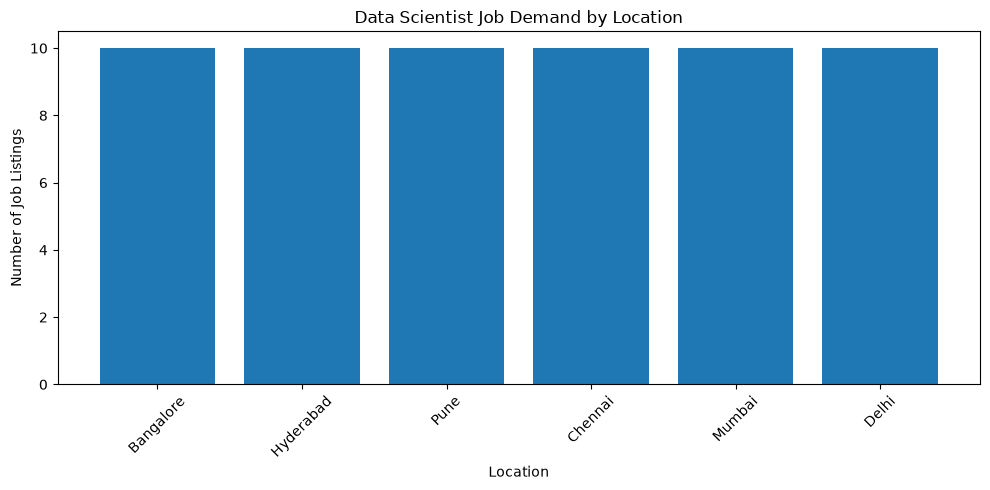

In [27]:
plt.figure(figsize=(10, 5))

plt.bar(
    location_analysis["Location"],
    location_analysis["Number of Jobs"]
)

plt.title("Data Scientist Job Demand by Location")
plt.xlabel("Location")
plt.ylabel("Number of Job Listings")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

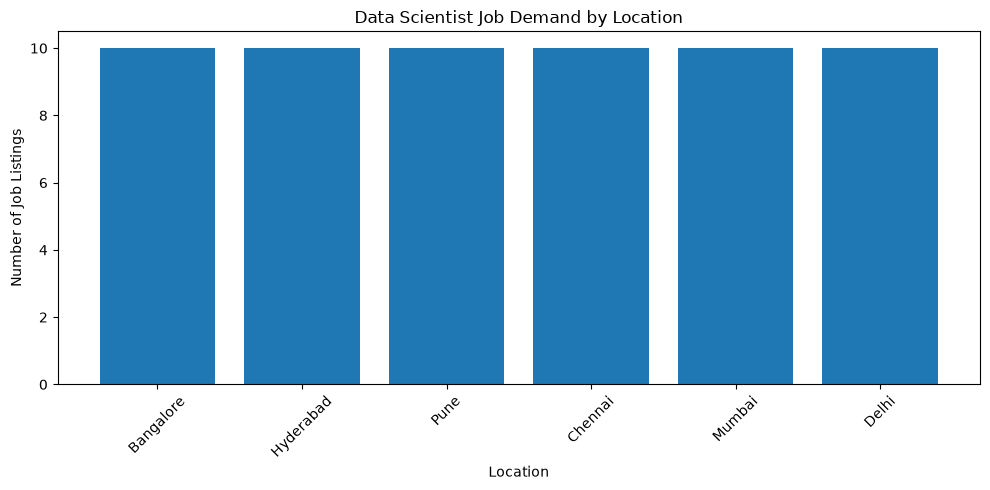

Graph saved successfully.


In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    location_analysis["Location"],
    location_analysis["Number of Jobs"]
)

plt.title("Data Scientist Job Demand by Location")
plt.xlabel("Location")
plt.ylabel("Number of Job Listings")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "job_demand_by_location.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully.")

In [29]:
city_df.to_csv(
    "job_market_multi_city.csv",
    index=False
)

print("Multi-city dataset saved successfully.")

Multi-city dataset saved successfully.


In [30]:
print("ONLINE JOB MARKET ANALYTICS")
print("-" * 35)

print("Job Role:", JOB_ROLE)
print("Total Jobs Analyzed:", len(city_df))
print("Cities Analyzed:", len(location_analysis))

print("\nLocation-wise Job Demand:")
print(location_analysis.to_string(index=False))

ONLINE JOB MARKET ANALYTICS
-----------------------------------
Job Role: data scientist
Total Jobs Analyzed: 60
Cities Analyzed: 6

Location-wise Job Demand:
 Location  Number of Jobs
Bangalore              10
Hyderabad              10
     Pune              10
  Chennai              10
   Mumbai              10
    Delhi              10


In [31]:
driver.quit()

print("Browser closed successfully.")

Browser closed successfully.
